# 03 — The A → B → C comparison

We estimate the income–health gradient three ways and ask how much it moves:

- **A. Midpoint + listwise deletion.** Assign each bracket its midpoint (open top
  bracket → \$250k), drop all missing income, run a survey-weighted logistic of FMD
  on log-income + covariates. The standard-practice baseline.
- **B. Grouped-data likelihood, missing dropped.** Same respondents (bracketed
  only), but income is interval-censored: a lognormal measurement model whose latent
  log-income is integrated through the logistic outcome. Isolates the effect of
  honoring the grouping and the open-ended top bracket.
- **C. Grouped-data likelihood + two-mechanism missingness.** Adds the missing
  respondents — don't-know as MAR given covariates, refused via an MNAR tilt (shown
  here at the ignorable value γ=0; the sensitivity sweep is notebook 04).

The **gradient** is the odds ratio of frequent mental distress per **doubling** of
household income; we expect it below 1 (more income → less distress).

**Design-based inference.** The primary 95% CI is a stratified Taylor-linearised
sandwich (`_STSTR` strata, `_LLCPWT` weights) — the standard design-based variance
for survey GLMs. We confirm it with a stratified bootstrap that refits the entire
pipeline (income model included), warm-started so it is affordable.

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import recode as rc
import income_model as im
import survey as sv

DATA = os.path.abspath(os.path.join('..', 'data'))
DERIVED = os.path.join(DATA, 'derived')
frame = pd.read_parquet(os.path.join(DERIVED, 'brfss_2023_analysis.parquet'))
d, colnames, strata = rc.frame_to_recoded(frame)
print(f'analysis sample: {d.X.shape[0]:,} rows, {d.X.shape[1]} covariates')

K = 32            # quadrature nodes for the main fits
K_BOOT = 24       # nodes for bootstrap replicates
B_BOOT = 50       # bootstrap replicates (warm-started; confirmation of the linearized CI)

analysis sample: 408,944 rows, 20 covariates


## Fit the three models on the full sample

In [2]:
t0 = time.time()
rA = im.fit_A(d)
rB = im.fit_B(d, K=K)
income = rB.income                      # reuse the bracketed income model for C
rC = im.fit_C(d, gamma=0.0, K=K, income=income)
print(f'fit A/B/C in {time.time()-t0:.1f}s')
for r in (rA, rB, rC):
    print(f'  {r.name:28s}  OR/doubling = {r.or_per_doubling:.4f}  '
          f'(theta={r.theta:+.4f})  n={r.n_used:,}')

fit A/B/C in 26.2s
  A_midpoint_listwise           OR/doubling = 0.8526  (theta=-0.2301)  n=338,056
  B_grouped_listwise            OR/doubling = 0.8364  (theta=-0.2577)  n=338,056
  C_two_mechanism(gamma=0)      OR/doubling = 0.8369  (theta=-0.2569)  n=408,944


## Design-based linearized 95% CIs (primary)

The linearized sandwich reuses the exact quadrature nodes each model fit on.

In [3]:
def linearized_ci(res, two_mech):
    if res.name.startswith('A'):
        m = d.mask('bracket')
        nodes = d.log_mid[m][:, None]
        X, y, w, st = d.X[m], d.y[m], d.w[m], strata[m]
    else:
        use, nodes = im.latent_nodes(d, res.income, K, gamma=(res.gamma or 0.0),
                                     two_mechanism=two_mech)
        X, y, w, st = d.X[use], d.y[use], d.w[use], strata[use]
    se = sv.linearized_se(res.outcome.params, X, y, w, nodes, st) * im.LN2
    return sv.CI(point=res.log_or_per_doubling, se=se,
                 lo=res.log_or_per_doubling - 1.96 * se,
                 hi=res.log_or_per_doubling + 1.96 * se, boot=np.array([]))

lin = {'A': linearized_ci(rA, False), 'B': linearized_ci(rB, False),
       'C': linearized_ci(rC, True)}
for k, ci in lin.items():
    print(f'  {k}: OR/doubling={np.exp(ci.point):.4f}  '
          f'linearized 95% CI [{np.exp(ci.lo):.4f}, {np.exp(ci.hi):.4f}]')

  A: OR/doubling=0.8526  linearized 95% CI [0.8333, 0.8723]
  B: OR/doubling=0.8364  linearized 95% CI [0.8162, 0.8572]
  C: OR/doubling=0.8369  linearized 95% CI [0.8166, 0.8576]


## Confirm with the stratified bootstrap (refits everything)

Each replicate resamples respondents within `_STSTR` strata and refits the income
*and* outcome models, warm-started from the full-sample fit. This propagates
income-model uncertainty too, so agreement with the linearized band validates
treating the income model as fixed.

In [4]:
fitters = {
    'A': lambda dd: im.fit_A(dd),
    'B': lambda dd: im.fit_B(dd, K=K_BOOT,
                             income_init=(rB.income.beta, rB.income.sigma),
                             outcome_init=rB.outcome.params),
    'C': lambda dd: im.fit_C(dd, gamma=0.0, K=K_BOOT,
                             income_init=(rC.income.beta, rC.income.sigma),
                             outcome_init=rC.outcome.params),
}
points = {'A': rA.log_or_per_doubling, 'B': rB.log_or_per_doubling,
          'C': rC.log_or_per_doubling}
t0 = time.time()
boot = sv.bootstrap_gradients(d, strata, fitters, B=B_BOOT, seed=2023,
                              points=points, log=print)
print(f'bootstrap ({B_BOOT} reps x 3 models) in {(time.time()-t0)/60:.1f} min')
for k in 'ABC':
    print(f'  {k}: boot SE={boot[k].se:.4f}  vs linearized SE={lin[k].se:.4f}  '
          f'(95% CI OR [{np.exp(boot[k].lo):.4f}, {np.exp(boot[k].hi):.4f}])')

  bootstrap 5/50


  bootstrap 10/50


  bootstrap 15/50


  bootstrap 20/50


  bootstrap 25/50


  bootstrap 30/50


  bootstrap 35/50


  bootstrap 40/50


  bootstrap 45/50


  bootstrap 50/50
bootstrap (50 reps x 3 models) in 20.6 min
  A: boot SE=0.0119  vs linearized SE=0.0117  (95% CI OR [0.8300, 0.8681])
  B: boot SE=0.0125  vs linearized SE=0.0125  (95% CI OR [0.8144, 0.8513])
  C: boot SE=0.0125  vs linearized SE=0.0125  (95% CI OR [0.8149, 0.8520])


## The income measurement model and the midpoint bias

The lognormal model spreads the open-ended top bracket over a real tail instead of
pinning everyone at \$250k. Because income is right-skewed, the bracket midpoint
understates mean income (Jensen's inequality).

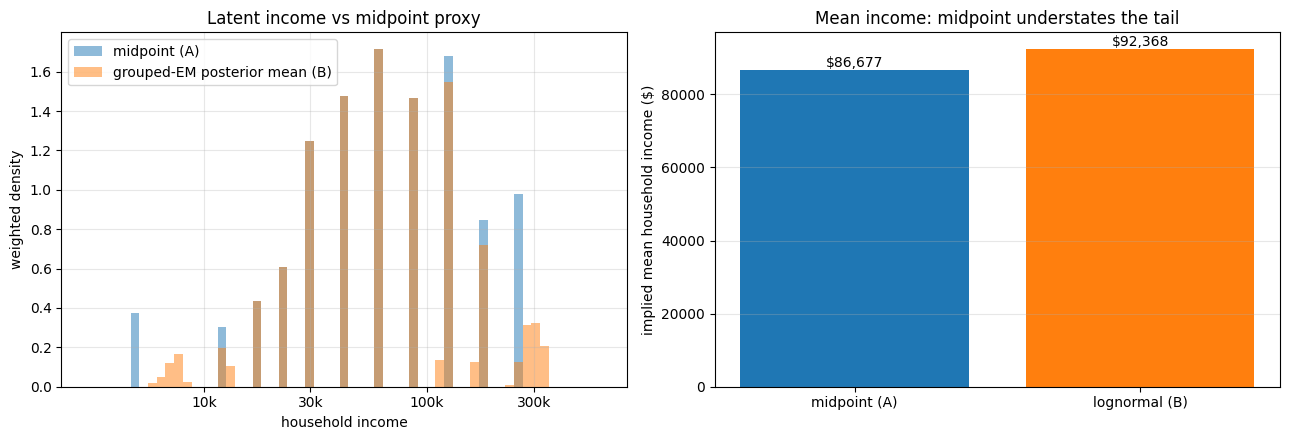

median household income (model B, at mean covariates): $62,190


In [5]:
m = d.mask('bracket')
mu = d.X[m] @ income.beta; sig = income.sigma; wbr = d.w[m]
post_mean = im._truncnorm_moments((d.log_lo[m] - mu) / sig, (d.log_hi[m] - mu) / sig,
                                  mu, sig)[0]
mid = d.log_mid[m]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.linspace(np.log(3000), np.log(600000), 60)
ax[0].hist(mid, bins=bins, weights=wbr, density=True, alpha=0.5, label='midpoint (A)')
ax[0].hist(post_mean, bins=bins, weights=wbr, density=True, alpha=0.5,
           label='grouped-EM posterior mean (B)')
ax[0].set_xticks(np.log([1e4, 3e4, 1e5, 3e5]))
ax[0].set_xticklabels(['10k', '30k', '100k', '300k'])
ax[0].set_xlabel('household income'); ax[0].set_ylabel('weighted density')
ax[0].set_title('Latent income vs midpoint proxy'); ax[0].legend(); ax[0].grid(alpha=0.3)

mean_mid = np.average(np.exp(mid), weights=wbr)
mean_logn = np.average(np.exp(mu + 0.5 * sig ** 2), weights=wbr)
ax[1].bar(['midpoint (A)', 'lognormal (B)'], [mean_mid, mean_logn], color=['C0', 'C1'])
ax[1].set_ylabel('implied mean household income ($)')
ax[1].set_title('Mean income: midpoint understates the tail')
for i, v in enumerate([mean_mid, mean_logn]):
    ax[1].text(i, v, f'${v:,.0f}', ha='center', va='bottom')
ax[1].grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()
print(f'median household income (model B, at mean covariates): '
      f'${np.exp(np.average(mu, weights=wbr)):,.0f}')

## The headline table

In [6]:
def row(label, res, ci):
    return {'model': label, 'OR per doubling': round(np.exp(res.log_or_per_doubling), 4),
            '95% CI low': round(np.exp(ci.lo), 4), '95% CI high': round(np.exp(ci.hi), 4),
            'log-OR/doubling': round(res.log_or_per_doubling, 4),
            'lin SE': round(ci.se, 4), 'n used': res.n_used}

table = pd.DataFrame([
    row('A. midpoint + listwise', rA, lin['A']),
    row('B. grouped + listwise', rB, lin['B']),
    row('C. grouped + two-mech (γ=0)', rC, lin['C']),
])
table.to_csv(os.path.join(DERIVED, 'brfss_income_ABC_table.csv'), index=False)
table

,model,OR per doubling,95% CI low,95% CI high,log-OR/doubling,lin SE,n used
0,A. midpoint + listwise,0.8526,0.8333,0.8723,-0.1595,0.0117,338056
1,B. grouped + listwise,0.8364,0.8162,0.8572,-0.1786,0.0125,338056
2,C. grouped + two-mech (γ=0),0.8369,0.8166,0.8576,-0.1781,0.0125,408944


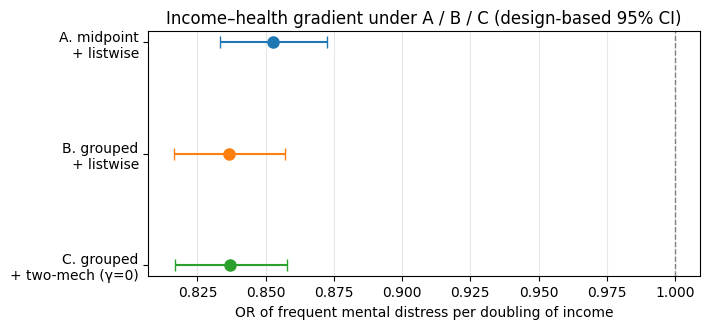

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
ys = [2, 1, 0]
labels = ['A. midpoint\n+ listwise', 'B. grouped\n+ listwise', 'C. grouped\n+ two-mech (γ=0)']
for y, key, res in zip(ys, 'ABC', [rA, rB, rC]):
    orp = np.exp(res.log_or_per_doubling)
    lo, hi = np.exp(lin[key].lo), np.exp(lin[key].hi)
    ax.errorbar([orp], [y], xerr=[[orp - lo], [hi - orp]], fmt='o', capsize=4, ms=8)
ax.axvline(1.0, color='gray', ls='--', lw=1)
ax.set_yticks(ys); ax.set_yticklabels(labels)
ax.set_xlabel('OR of frequent mental distress per doubling of income')
ax.set_title('Income–health gradient under A / B / C (design-based 95% CI)')
ax.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()